# Model Selection

**Sections**
- [Setup](#Setup)
- [Load data](#Load-data)
- [Baseline Model Evaluation](#Baseline-Model-Evaluation)
- [FGLS Model](#FGLS-Model)
- [Results](#Results)

We start by loading our training set. This training set was created in the notebook `train_test_split`; we save the testing set for the final modeling step, which will follow this model selection.

In our "Baseline Model Evaluation" section, we evaluate baseline models `Dummy`, `Linear`, `Ridge`, `Lasso`, `Poisson`, and `RandomForest`. We instantiate each model as a pipeline. For each model, we first have a preprocessing step consisting of an `Imputer` followed by a `Standard Scaler`. We also have versions that include `PCA` and versions that include `Interactions`, resulting in 10 different pipelines. We proceed with a county-aware cross-validation to ensure that census tracts from the same county do not end up in both the training and hold-out sets. We use GridsearchCV to tune our hyperparameters for `Ridge`, `Lasso`, `PCA`, and `RandomForest`.

In our "FGLS Model" section, we implement manually an FGLS model (feasible generalized least squares) to try to account for the errors in health outcomes (each health outcome is estimated using BRFSS and demographics data and comes with confidence intervals). We also detail the approach, which is based on the following [paper](https://www.jstor.org/stable/pdf/25791822.pdf?casa_token=N0BnCWKeyXEAAAAA:zpUTCEulSLZaUusXK78zRF6oIMlStssy-Q8E0MgtPalPAsdhX10pAM3BlexT-Dgp9ZuE3HSiKWeZGZNoF_d4tcJ_tTp8Q57ZVxYtY0znSW3Ewu38Xod2zA) mentioned by the CDC as a recommendation to tackle problems where the outcomes are estimated from a model.

Unfortunately, across all outcomes, no model showed significant improvement over the dummy baseline under county-aware GroupKFold. This result suggests that the four walkability rank features, on their own, carry a limited predictive signal for tract-level health prevalence in our setting. We therefore report `RandomForestRegressor` as the best among the tested models and chose it as our final model. However, we emphasize that its gains over dummy are small; additional covariates may be necessary to obtain practically useful accuracy.

## Setup

In [1]:
# Setup

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    GroupKFold,
    cross_validate,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, PoissonRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
import os
import matplotlib.pyplot as plt

## Load Data

In [2]:
# load the clean datasets

df = pd.read_csv("data_train.csv")

## Baseline Model Evaluation

### Configuration

In [3]:
features = [
    "employment_mix_ranked",
    "employment_residential_mix_ranked",
    "intersection_density_ranked",
    "transit_accessibility_ranked",
]

outcomes = [
    "high_cholesterol_prevalence",
    "depression_prevalence",
    "high_blood_pressure_prevalence",
    "obesity_prevalence",
    "cancer_prevalence",
]

group_col = "StCoFIPS2019"
n_splits = 5

### Pre-processing steps

In [4]:
# Plain: impute missing values with median strategy and apply standard scaler
pre_plain = ColumnTransformer(
    [
        (
            "num",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="median")),
                    ("sc", StandardScaler()),
                ]
            ),
            features,
        )
    ],
    remainder="drop",
)


# Interactions: impute + pairwise interactions + standard scaler
#   4 mains feature + 6 interaction terms = 10 features total
pre_inter = ColumnTransformer(
    [
        (
            "num",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="median")),
                    (
                        "poly",
                        PolynomialFeatures(
                            degree=2, interaction_only=True, include_bias=False
                        ),
                    ),
                    ("sc", StandardScaler()),
                ]
            ),
            features,
        )
    ],
    remainder="drop",
)

### Pipelines

In [5]:
# Base models
pipe_linear = Pipeline([("pre", pre_plain), ("lr", LinearRegression())])

pipe_pca_linear = Pipeline(
    [("pre", pre_plain), ("pca", PCA()), ("lr", LinearRegression())]
)

pipe_ridge = Pipeline([("pre", pre_plain), ("ridge", Ridge())])

pipe_lasso = Pipeline([("pre", pre_plain), ("lasso", Lasso(max_iter=10000))])

pipe_glm_poisson = Pipeline(
    [("pre", pre_plain), ("glm", PoissonRegressor(max_iter=1000, alpha=0.1))]
)

pipe_rf = Pipeline(
    [("pre", pre_plain), ("rf", RandomForestRegressor(random_state=42, n_jobs=-1))]
)

# Interaction models
pipe_linear_inter = Pipeline([("pre", pre_inter), ("lr", LinearRegression())])
pipe_ridge_inter = Pipeline([("pre", pre_inter), ("ridge", Ridge())])
pipe_lasso_inter = Pipeline([("pre", pre_inter), ("lasso", Lasso(max_iter=10000))])
pipe_pca_inter = Pipeline(
    [("pre", pre_inter), ("pca", PCA()), ("lr", LinearRegression())]
)

### Hyper-parameters

In [6]:
grid_pca_linear = {"pca__n_components": [2, 3, 4]}
grid_ridge = {"ridge__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
grid_lasso = {"lasso__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
grid_pca_inter = {"pca__n_components": [2, 3, 4, 5, 6, 7, 8, 9, 10]}

grid_rf = {
    "rf__n_estimators": [200],
    "rf__max_depth": [5, 10, None],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 3, 5],
    "rf__max_features": ["sqrt", "log2", 1.0],
}

### Cross-validation

In [7]:
# GroupKFold splits our data set so that different folds have disjoint county codes
gkf = GroupKFold(n_splits=n_splits)

# Helper: convert neg MSE scores to RMSE mean & sd
"""
cross_validate has a scoring = "neg_mean_squared_error" option. Since we are intereste in the root mean squared error,
we create a small function that takes the score (the list of neg_mean_squared_error across splits) and return the mean
and standard deviation of the root mean squared errors.
"""


def mean_rmse_from_neg_mse(scores):
    mses = -np.array(scores, dtype=float)
    rmses = np.sqrt(mses)
    return float(rmses.mean()), float(rmses.std())


# Results rows
"""
We create an empty row, which will be a list of dictionaries that we can turn into a data set at the end of our 
cross validation.
"""
rows = []

"""
We apply our cross validation strategy to each outcome.
"""
for target in outcomes:
    cols_needed = features + [target, group_col]
    d = df.dropna(
        subset=cols_needed
    ).copy()  # we drop the rows with missing values in cols_needed

    X = d[features]
    y = d[target]
    groups = d[group_col]

    # 0) Dummy baseline (predicts mean per train fold)
    cv_dummy = cross_validate(
        DummyRegressor(strategy="mean"),
        X,
        y,
        cv=gkf.split(X, y, groups=groups),
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        return_train_score=False,
    )
    rmse_mean, rmse_sd = mean_rmse_from_neg_mse(cv_dummy["test_score"])
    rows.append(
        {
            "target": target,
            "model": "dummy",
            "rmse_mean": rmse_mean,
            "rmse_sd": rmse_sd,
            "details": "",
        }
    )

    # 1a) Linear
    cv_lin = cross_validate(
        pipe_linear,
        X,
        y,
        cv=gkf.split(X, y, groups=groups),
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        return_train_score=False,
    )
    rmse_mean, rmse_sd = mean_rmse_from_neg_mse(cv_lin["test_score"])
    rows.append(
        {
            "target": target,
            "model": "linear",
            "rmse_mean": rmse_mean,
            "rmse_sd": rmse_sd,
            "details": "",
        }
    )

    # 1b) Linear + interactions
    cv_lin_inter = cross_validate(
        pipe_linear_inter,
        X,
        y,
        cv=gkf.split(X, y, groups=groups),
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        return_train_score=False,
    )
    rmse_mean, rmse_sd = mean_rmse_from_neg_mse(cv_lin_inter["test_score"])
    rows.append(
        {
            "target": target,
            "model": "linear + inter",
            "rmse_mean": rmse_mean,
            "rmse_sd": rmse_sd,
            "details": "",
        }
    )

    # 2a) PCA + Linear (tune n_components)
    gs_pca_linear = GridSearchCV(
        pipe_pca_linear,
        grid_pca_linear,
        scoring="neg_mean_squared_error",
        cv=gkf.split(X, y, groups=groups),
        n_jobs=-1,
    )
    gs_pca_linear.fit(X, y)
    rows.append(
        {
            "target": target,
            "model": "PCA + linear",
            "rmse_mean": float(np.sqrt(-gs_pca_linear.best_score_)),
            "rmse_sd": np.nan,
            "details": f"best n_components={gs_pca_linear.best_params_.get('pca__n_components')}",
        }
    )

    # 2b) PCA + Linear + inter (tune n_components)
    gs_pca_inter = GridSearchCV(
        pipe_pca_inter,
        grid_pca_inter,
        scoring="neg_mean_squared_error",
        cv=gkf.split(X, y, groups=groups),
        n_jobs=-1,
    )
    gs_pca_inter.fit(X, y)
    rows.append(
        {
            "target": target,
            "model": "PCA + linear + inter",
            "rmse_mean": float(np.sqrt(-gs_pca_inter.best_score_)),
            "rmse_sd": np.nan,
            "details": f"best n_components={gs_pca_inter.best_params_.get('pca__n_components')}",
        }
    )

    # 3a) Ridge (tune alpha)
    gs_ridge = GridSearchCV(
        pipe_ridge,
        grid_ridge,
        scoring="neg_mean_squared_error",
        cv=gkf.split(X, y, groups=groups),
        n_jobs=-1,
    )
    gs_ridge.fit(X, y)
    rows.append(
        {
            "target": target,
            "model": "Ridge",
            "rmse_mean": float(np.sqrt(-gs_ridge.best_score_)),
            "rmse_sd": np.nan,
            "details": f"best alpha={gs_ridge.best_params_.get('ridge__alpha')}",
        }
    )

    # 3b) Ridge + inter (tune alpha)
    gs_ridge_inter = GridSearchCV(
        pipe_ridge_inter,
        grid_ridge,
        scoring="neg_mean_squared_error",
        cv=gkf.split(X, y, groups=groups),
        n_jobs=-1,
    )
    gs_ridge_inter.fit(X, y)
    rows.append(
        {
            "target": target,
            "model": "Ridge + inter",
            "rmse_mean": float(np.sqrt(-gs_ridge_inter.best_score_)),
            "rmse_sd": np.nan,
            "details": f"best alpha={gs_ridge_inter.best_params_.get('ridge__alpha')}",
        }
    )

    # 4a) Lasso (tune alpha)
    gs_lasso = GridSearchCV(
        pipe_lasso,
        grid_lasso,
        scoring="neg_mean_squared_error",
        cv=gkf.split(X, y, groups=groups),
        n_jobs=-1,
    )
    gs_lasso.fit(X, y)
    rows.append(
        {
            "target": target,
            "model": "Lasso",
            "rmse_mean": float(np.sqrt(-gs_lasso.best_score_)),
            "rmse_sd": np.nan,
            "details": f"best alpha={gs_lasso.best_params_.get('lasso__alpha')}",
        }
    )

    # 4b) Lasso + inter (tune alpha)
    gs_lasso_inter = GridSearchCV(
        pipe_lasso_inter,
        grid_lasso,
        scoring="neg_mean_squared_error",
        cv=gkf.split(X, y, groups=groups),
        n_jobs=-1,
    )
    gs_lasso_inter.fit(X, y)
    rows.append(
        {
            "target": target,
            "model": "Lasso + inter",
            "rmse_mean": float(np.sqrt(-gs_lasso_inter.best_score_)),
            "rmse_sd": np.nan,
            "details": f"best alpha={gs_lasso_inter.best_params_.get('lasso__alpha')}",
        }
    )

    # GLM Poisson
    # ensure non-negative target
    y_poisson = y.clip(lower=0)
    cv_glm_poisson = cross_validate(
        pipe_glm_poisson,
        X,
        y_poisson,
        cv=gkf.split(X, y_poisson, groups=groups),
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    rmse_mean, rmse_sd = mean_rmse_from_neg_mse(cv_glm_poisson["test_score"])
    rows.append(
        {
            "target": target,
            "model": "GLM Poisson",
            "rmse_mean": rmse_mean,
            "rmse_sd": rmse_sd,
            "details": "",
        }
    )

    # Random Forest + GridSearch
    gs_rf = GridSearchCV(
        pipe_rf,
        grid_rf,
        scoring="neg_mean_squared_error",
        cv=gkf.split(X, y, groups=groups),
        n_jobs=-1,
    )
    gs_rf.fit(X, y)
    rows.append(
        {
            "target": target,
            "model": "Random Forest",
            "rmse_mean": float(np.sqrt(-gs_rf.best_score_)),
            "rmse_sd": np.nan,
            "details": f"best params={gs_rf.best_params_}",
        }
    )

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


### FGLS Model

**Sections**
- [Idea](#Idea)
- [Finding the weigths](#Finding-the-weigths)
- [Creating the model](#Creating-the-model)
- [Cross-validation FGLS](#Cross-validation-FGLS)

#### Idea

The FGLS model (Feasible Generalized Least Squares) is relevant in the case where we do not have access to the true dependent variable $y$, but have access to estimated dependent variables $y^*$ coming from estimates, and have an idea of the errors made by such estimates. For example, in our case, we do not have the true obesity prevalence rate for each tract; we only have access to estimates based on BRFSS (health surveys) and ACS (demographics) data. Furthermore, we have confidence intervals for each estimate, which allow us to estimate the errors made.

The FGLS model is explained in the following [paper](https://www.jstor.org/stable/pdf/25791822.pdf?casa_token=N0BnCWKeyXEAAAAA:zpUTCEulSLZaUusXK78zRF6oIMlStssy-Q8E0MgtPalPAsdhX10pAM3BlexT-Dgp9ZuE3HSiKWeZGZNoF_d4tcJ_tTp8Q57ZVxYtY0znSW3Ewu38Xod2zA), but we give a sketch below. We assume a linear regression model of the form:
$$
y = \beta_0 + \sum_{j=1}^k\beta_j x_{j} + \epsilon = \vec{x} \cdot \vec{\beta} + \epsilon,
$$
where:
$$
\vec{x} \coloneqq \left(1, x_1,\dots, x_k \right)^\top\\
\vec{\beta} \coloneqq \left(\beta_0, \beta_1, \dots, \beta_k \right)^\top
$$
and $\epsilon \sim N(0,\sigma^2)$ is an error term independent of $\vec{x}$.

We assume that we have access to independant observations $\vec{x}_i$ ($i = 1, \cdots, N$) and, for each $i$, an estimated outcome $y_i^*$ related to the true outcome $y_i$ by the relation:
$$
y_i^* = y_i + u_i,
$$
where $u_i \sim N(0,\omega_i^2)$. We also assume all estimates are independent from one another and $Cov(u_i,u_j) = 0$ for every $i \neq j$.

The relations imply:
$$
y_i^* =  \vec{x}_i \cdot \vec{\beta} + \epsilon_i + u_i,\ j=1,\cdots,N.
$$
If we don't have $\omega_i = \omega_j$ for all $i \neq j$, then the errors $\epsilon_i + u_i$ don't have the same variance, and the model is heteroskedastic.  To correct this, we multiply by weight:
$$
\boxed{\lambda_i \coloneqq \frac{1}{\sqrt{\sigma^2+\omega_i^2}}},
$$
so that:
$$
\lambda_iy_i^* = \lambda_i\vec{x}_i \cdot \vec{\beta} + \lambda_i(\epsilon_i + u_i),\ j=1,\cdots,N,
$$
where $\lambda_i(\epsilon_i + u_i) \sim N(0,1)$. In this case, the model is homoscedastic and one can apply OLS to obtain $\vec{\beta}$. We can then compute residues by the formula:
$$
\boxed{r_i =  y_i^* - \vec{x}_i \cdot \vec{\beta}}, 
$$
and score our model. The coefficients $\vec{\beta}$ can be obtained using the usual OLS formula. More precisely, denoting $\boxed{W = diag(\lambda_1^2,\cdots,\lambda_N^2)}$, $X$ our design matrix, $Y$ our outcomes columns, and $v$ our column of errors $(\epsilon_i + u_i)$, we have:
$$
W^{1/2}Y = W^{1/2}X\vec{\beta} + W^{1/2}v.
$$
Therefore, denoting $\tilde{X} = W^{1/2}X$ and $\tilde{Y} = W^{1/2} Y$, we have:
$$
\vec{\beta} = (\tilde{X}^\top\tilde{X})^{-1}\tilde{X}^\top \tilde{Y} = \boxed{(X^\top W X)^{-1}X^\top W Y = \vec{\beta}}.
$$

#### Finding the weigths

##### Estimating $\omega_i$'s

In our case, we can compute $\omega_i$ using confidence intervals. More precisely, we have confidence intervals $[L_i, U_i]$ defined as $L_i = y_i^* - z_{0.975}\omega_i$ and $U_i = y_i^* + z_{0.975}\omega_i$, where $z_{0.975}$ is the 97.5th percentile of the standard normal distribution, i.e., $z_{0.975}\simeq 1.96$. Therefore:
$$
\boxed{\omega_i \simeq \frac{U_i-L_i}{2*1.96}}.
$$

##### Estimating $\sigma$

While we know $\omega_i$'s, we do not know $\sigma$, and one can apply the method described in Section 4.3 of the following [paper](https://www.jstor.org/stable/pdf/25791822.pdf?casa_token=N0BnCWKeyXEAAAAA:zpUTCEulSLZaUusXK78zRF6oIMlStssy-Q8E0MgtPalPAsdhX10pAM3BlexT-Dgp9ZuE3HSiKWeZGZNoF_d4tcJ_tTp8Q57ZVxYtY0znSW3Ewu38Xod2zA) mentioned previously.

We run OLS on $y_i^* = \vec{x}_i \cdot \vec{\beta}  + \epsilon_i + u_i,\ j=1,\cdots,N$ even though we don't have homoskedacity. Thanks to the [paper](https://www.jstor.org/stable/pdf/25791822.pdf?casa_token=N0BnCWKeyXEAAAAA:zpUTCEulSLZaUusXK78zRF6oIMlStssy-Q8E0MgtPalPAsdhX10pAM3BlexT-Dgp9ZuE3HSiKWeZGZNoF_d4tcJ_tTp8Q57ZVxYtY0znSW3Ewu38Xod2zA), we have the following unbiased estimate for $\sigma$:
$$
\hat{\sigma}^2 = \max\Bigg\{\frac{\sum_{i=1}^N r_i^2 - \sum_{i=1}^N\omega_i^2 + tr((X^\top X)^{-1} X^\top G X)}{N-k-1}, 0\Bigg\},
$$
where $\boxed{r_i = y_i^* - \vec{x}_i\cdot\vec \beta}$ are our residues, $X$ is the $(N,k)$ matrix whose $i$-th row is $(1, x_{i1},\cdots, x_{ik})$, and $G = diag(\omega_1^2, \cdots, \omega_N^2)$. Note that in our case, we have $k$ features, while they have $k-1$ in the paper (see eq. (1)), so we replace their $k$ with $k+1$. Moreover, we have:
$$
tr((X^\top X)^{-1} X^\top G X) = tr(X(X^\top X)^{-1} X^\top G) = tr(HG) = \sum_{i=1}^N(HG)_{ii}=\sum_{i,j=1}^NH_{ij}G_{ij} = \sum_{i,j=1}^NH_{ij}\delta_{ij}\omega_i^2 = \sum_{i,j=1}^NH_{ii}\omega_i^2,
$$
where $\boxed{H = X(X^\top X)^{-1} X^\top}$ is the 'hat' matrix. Conclusion:
$$
\boxed{\hat{\sigma}^2 = \max\Bigg\{\frac{\sum_{i=1}^N r_i^2 +\omega_i^2(H_{ii}-1)}{N-k-1}, 0\Bigg\}}.
$$

#### Creating the model

##### Helper functions

In [8]:
Z975 = 1.96  # 97.5th percentile of N(0,1), we will use it to recover standard errores from the 95% CIs


def parse_ci_column(ci_values):
    """
    Our CI column consists of strings of the form "(33.4, 36.5)". This function splits the CI column into two
    float arrays, one that contains the CI lower bounds (L) and the other containing the CI upper bounds (U).

    Parameters:
    ci_values = array-like with shape (N,) or (N, 1), where each element is expected to be a string like "(a, b)" or "[a, b]".

    Returns:
    L = array with shape (N,), which is the lower CI bound for each row.
    U = aray with shape (N,), which is the upper CI bound for each row.
    """
    # Convert to a 1D array of strings.
    # .ravel() flattens (N,1) to (N,), .astype(str) ensures string operations work.
    s = np.asarray(ci_values).ravel().astype(str)

    # Preallocate outputs with NaN so any failed parse stays NaN.
    L = np.full(s.shape, np.nan, float)
    U = np.full(s.shape, np.nan, float)

    for i, txt in enumerate(s):
        # Removes first whitespace and outer parentheses/brackets.
        txt = txt.strip().strip("()[]")

        # Split on the first comma; trim spaces around each piece.
        parts = [p.strip() for p in txt.split(",")]

        L[i] = float(parts[0])  # first number  is the lower bound
        U[i] = float(parts[1])  # second number is the upper bound

    return L, U


def omega_from_ci(L, U, z: float = Z975) -> np.ndarray:
    """
    This function recovers the per-observation standard errors omega_i from our 95% confidence intervals.

    Parameters:
    L = array-like (N,), Lower CI bound for each observation.
    U = array-like (N,), Upper CI bound for each observation.
    z = float, Critical value for the CI (default 1.96 for 95% two-sided).

    Returns:
    omega = array with shape (N,), which contains our standard errors omega_i's.

    Math:
    If CI is [L_i, U_i], then omega_i sim (U_i - L_i) / (2z) assuming estimates are drown from a randowm variable with normal noise.
    """
    L = np.asarray(L, dtype=float)
    U = np.asarray(U, dtype=float)

    return (U - L) / (2.0 * z)


def standardize_train_apply(X_tr: np.ndarray, X_te: np.ndarray):
    """
    StandardScale features column-wise using the training set only to avoid leakage.
    Return the standardized train/test plus the mean and std used.

    Parameters:
    X_tr = ndarray of shape (n_train, k)
    X_te = ndarray of shape (n_test,  k)

    Returns:
    X_tr_s = ndarray (n_train, k) StandardScale train
    X_te_s = ndarray (n_test,  k) StandardScale test using train mu/std
    mu = ndarray (k,) column means from train
    sd = ndarray (k,) column stds  from train (zero handled)
    """
    mu = X_tr.mean(axis=0)
    sd = X_tr.std(axis=0, ddof=0)

    X_tr_s = (X_tr - mu) / sd
    X_te_s = (X_te - mu) / sd

    return X_tr_s, X_te_s, mu, sd


def add_intercept(X: np.ndarray) -> np.ndarray:
    """
    Add a column of ones as the first column, which makes the design matrix shape (n, p) with p = k + 1.

    Parameters:
    X = ndarray (n, k)

    Returns:
    X_i = ndarray (n, k+1), where [1, x_1, ..., x_k] per row
    """
    n = X.shape[0]
    ones = np.ones((n, 1), dtype=float)

    return np.hstack([ones, X])


def hat_diag(X: np.ndarray) -> np.ndarray:
    """
    Compute the diagonal coefficients of the "hat matrix" H, i.e., h_ii = x_i^T (X^T X)^{-1} x_i.

    Parameters:
    X = array (n, p), Design matrix with its leading column of ones.

    Returns:
    h = array (n,), diagonal coefficients of H.
    """
    X = np.asarray(X, float)
    n, p = X.shape

    # A = (X^T X)^{-1}
    XtX = X.T @ X  # shape (p, p)
    A = np.linalg.inv(XtX)  # shape (p, p)

    h = np.zeros(n, dtype=float)
    for i in range(n):
        xi = X[i, :].reshape(p, 1)  # column vector (p, 1)
        # x_i^T A x_i = ( (x_i^T A) @ x_i )
        tmp = A @ xi  # (p,1)
        h[i] = float((xi.T @ tmp)[0, 0])

    return h

In [9]:
def fit_ols(X: np.ndarray, y: np.ndarray):
    """
    Manual OLS, which will be the first step of our FGLS model.

    Parameters:
    X = ndarray (n, p) design matrix with its leading column of ones.
    y = ndarray (n,) outcome vector

    Returns:
    beta = ndarray (p,), OLS coefficients
    resid = ndarray (n,), residuals r = y - X beta
    """
    XtX = X.T @ X
    XtX_inv = np.linalg.inv(XtX)
    beta = XtX_inv @ (X.T @ y)
    resid = y - X @ beta
    return beta, resid


def fit_fgls_train(X_tr: np.ndarray, y_tr: np.ndarray, omega_tr: np.ndarray):
    """
    Two-step FGLS on the train split only.

    Parameters:
    X_tr = ndarray (n_train, p), design matrix with its leading columns of ones
    y_tr = ndarray (n_train,), point estimates
    omega_tr = ndarray (n_train,), per-row SEs

    Returns:
    beta_wls = ndarray (p,), WLS coefficients
    sigma2 = float, estimated extra variance (u_i variance)

    Math:
    1) OLS on train gives residuals r and the "hat matrix" diagonal coefficients h_ii.
    2) Estimate sigma^2 by:
          sigma^2_hat = max{ (sum r_i^2 - sum (1 - h_ii) * omega_i^2) / (n - p), 0 }
       where:
          n = number of rows in X_tr, p = number of columns in X_tr (including the intercept).
    3) WLS weights on train:
          w_i = 1 / (omega_i^2 + sigma^2_hat)
       Then solve weighted normal equations to get beta_wls.
    """
    # Step 1: OLS
    _, resid = fit_ols(X_tr, y_tr)  # resid shape (n_train,)
    h = hat_diag(X_tr)  # h_ii shape (n_train,)

    n, p = X_tr.shape
    num = np.sum(resid**2) - np.sum((1.0 - h) * (omega_tr**2))  # Numerator for sigma^2

    den = n - p  # residual degrees of freedom

    sigma2 = num / den
    sigma2 = max(sigma2, 0.0)  # makes sure sigma2 >= 0

    # Step 2: WLS
    var = omega_tr**2 + sigma2
    w = (
        1.0 / var
    )  # Using the notations in the text above, we have W = diag(w_1, ..., w_N), i.e., this is the diagonal matrix of the lambda_i^2.

    # Weighted normal equations:
    # (X^T W X) beta = X^T W y
    # Here W is diagonal with w_i, so X^T W is just (X^T * w).
    XtW = (
        X_tr.T * w
    )  # shape (p, n_train), this is a quicker way than matrix multiplication, it just multiply each column element by w.
    XtWX = XtW @ X_tr  # shape (p, p)
    XtWy = XtW @ y_tr  # shape (p,)
    beta_wls = np.linalg.inv(XtWX) @ XtWy  # solve for beta

    return beta_wls, sigma2


def fgls_groupkfold_cv(
    X: np.ndarray,
    y: np.ndarray,
    omega: np.ndarray,
    groups,
    n_splits: int = 5,
):
    """
    Manual GroupKFold cross-validation for our two-step FGLS.

    Parameters:
    X = ndarray (N, k), features without the leading column of ones.
    y = ndarray (N,), Point estimates
    omega = ndarray (N,), Per-row standrd errors dervied from our CIs.
    groups = array-like (N,), Group labels for GroupKFold.
    n_splits = int, Number of CV folds.

    Returns:
    dict with keys:
        - "fold_metrics": list of dictionary per folds containing metrics (the way we made it, it only contain the RMSE, but we could easily add any other metrics)
        - "avg_RMSE": average RMSE accross folds
        - "betas_per_fold": list of beta vectors (p,) per fold
        - "sigma2_per_fold": list of sigma^2 scalars per fold

    Procedure:
    For each fold:
      1) Split indices into train/val by group.
      2) standardize X using TRAIN mean/std only.
      3) Add intercept column to both train and val matrices.
      4) Fit two-step FGLS on TRAIN (compute sigma^2_hat and beta_WLS).
      5) Predict on VAL using X_val @ beta_WLS.
      6) Compute RMSE for that fold.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    omega = np.asarray(omega, dtype=float)
    gkf = GroupKFold(n_splits=n_splits)

    fold_metrics = []
    coefs = []
    sigmas = []

    for fold, (idx_tr, idx_te) in enumerate(gkf.split(X, y, groups), 1):
        # Split into train/val for this fold
        X_tr, X_te = X[idx_tr], X[idx_te]
        y_tr, y_te = y[idx_tr], y[idx_te]
        om_tr = omega[idx_tr]

        # Standard scale
        X_tr_s, X_te_s, _, _ = standardize_train_apply(X_tr, X_te)

        # Add column of ones after scaling
        X_tr_i = add_intercept(X_tr_s)  # shape (n_train, k+1)
        X_te_i = add_intercept(X_te_s)  # shape (n_test,  k+1)

        # Fit FGLS on TRAIN only (get beta and sigma^2_hat)
        beta_wls, sigma2 = fit_fgls_train(X_tr_i, y_tr, om_tr)

        # Predict on VALIDATION split
        y_pred = X_te_i @ beta_wls

        # Compute RMSE on VALIDATION
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))

        # Record results for this fold
        fold_metrics.append({"fold": fold, "RMSE": rmse})
        coefs.append(beta_wls)
        sigmas.append(sigma2)

    # Aggregate across folds
    avg_rmse = np.mean([m["RMSE"] for m in fold_metrics])

    return {
        "fold_metrics": fold_metrics,
        "avg_RMSE": avg_rmse,
        "betas_per_fold": coefs,
        "sigma2_per_fold": sigmas,
    }

##### Cross-validation FGLS

In [10]:
"""
We apply our cross validation strategy to each outcome.
"""

for target in outcomes:

    cols_needed = features + [target, group_col]
    d = df.dropna(subset=cols_needed).copy()
    X = d[features]
    y = d[target]
    groups = d[group_col]

    ci_col = target.replace("_prevalence", "_95ci") # get the name of the CI column
    L, U = parse_ci_column(d[ci_col].values) # parse the CI column to get the lower and upper confidence interval
    omega = omega_from_ci(L, U) # get the standard errors

    # run manual FGLS cross-validation
    cv_fgls = fgls_groupkfold_cv(
        X,
        y,
        omega=omega,
        groups=groups,
        n_splits=n_splits,
    )

    # summarize to mean / sd RMSE across folds
    rmses = np.array([m["RMSE"] for m in cv_fgls["fold_metrics"]], float)
    rows.append(
        {
            "target": target,
            "model": "FGLS",
            "rmse_mean": float(rmses.mean()),
            "rmse_sd": float(rmses.std()),
            "details": f"sigma2 mean={np.mean(cv_fgls['sigma2_per_fold']):.4g}",
        }
    )

# Create a data set out of the results and save them.
results = pd.DataFrame(rows).sort_values(["target", "rmse_mean"])
print(results)
results.to_csv("results_cv_by_outcome.csv", index=False)

                            target                 model  rmse_mean   rmse_sd  \
54               cancer_prevalence         Random Forest   1.703717       NaN   
46               cancer_prevalence        linear + inter   1.721509  0.035512   
50               cancer_prevalence         Ridge + inter   1.721827       NaN   
48               cancer_prevalence  PCA + linear + inter   1.721875       NaN   
52               cancer_prevalence         Lasso + inter   1.721882       NaN   
45               cancer_prevalence                linear   1.721985  0.035342   
59               cancer_prevalence                  FGLS   1.722003  0.035176   
49               cancer_prevalence                 Ridge   1.722342       NaN   
51               cancer_prevalence                 Lasso   1.722347       NaN   
47               cancer_prevalence          PCA + linear   1.722347       NaN   
53               cancer_prevalence           GLM Poisson   1.723230  0.035075   
44               cancer_prev

### Results

#### Primary KPI = RMSE

In [11]:
# Best model per outcome in alphabetical order.
best_rows = (
    results.loc[results.groupby("target")["rmse_mean"].idxmin()]
    .sort_values("target")
    .reset_index(drop=True)
)

# Win counts by model
win_counts = (
    best_rows["model"].value_counts().rename_axis("model").reset_index(name="wins")
)

# Overall leaderboard = average RMSE across all outcomes
leaderboard = (
    results.groupby("model", as_index=False)
    .agg(
        avg_rmse=("rmse_mean", "mean"),
        sd_rmse=("rmse_mean", "std"),
        outcomes_covered=("target", "nunique"),
    )
    .sort_values("avg_rmse")
)

display(best_rows)
display(win_counts)
display(leaderboard)

,target,model,rmse_mean,rmse_sd,details
0,cancer_prevalence,Random Forest,1.703717,NaN,"best params={'rf__max_depth': 10, 'rf__max_fea..."
1,depression_prevalence,Random Forest,3.200421,NaN,"best params={'rf__max_depth': 5, 'rf__max_feat..."
2,high_blood_pressure_prevalence,Random Forest,6.834265,NaN,"best params={'rf__max_depth': 10, 'rf__max_fea..."
3,high_cholesterol_prevalence,Random Forest,4.212953,NaN,"best params={'rf__max_depth': 5, 'rf__max_feat..."
4,obesity_prevalence,Random Forest,6.062234,NaN,"best params={'rf__max_depth': 10, 'rf__max_fea..."


,model,wins
0,Random Forest,5


,model,avg_rmse,sd_rmse,outcomes_covered
6,Random Forest,4.402718,2.087615,5
11,linear + inter,4.465517,2.125463,5
8,Ridge + inter,4.466969,2.126189,5
3,Lasso + inter,4.467014,2.126191,5
5,PCA + linear + inter,4.467043,2.126215,5
10,linear,4.503459,2.158932,5
0,FGLS,4.503508,2.158913,5
4,PCA + linear,4.504513,2.159524,5
7,Ridge,4.505016,2.159818,5
2,Lasso,4.505028,2.159821,5


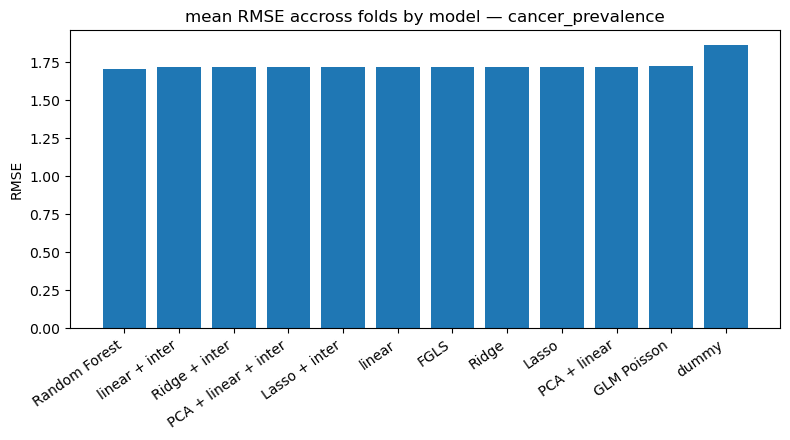

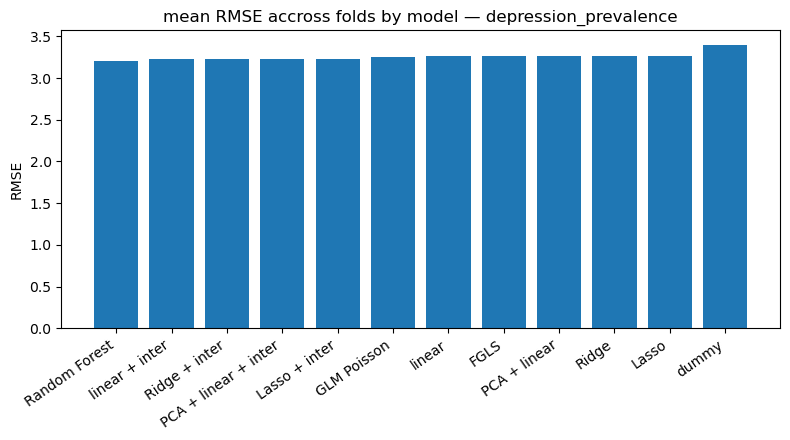

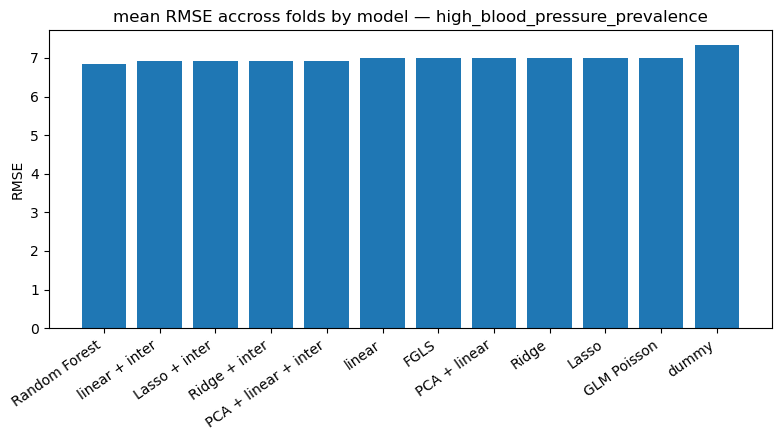

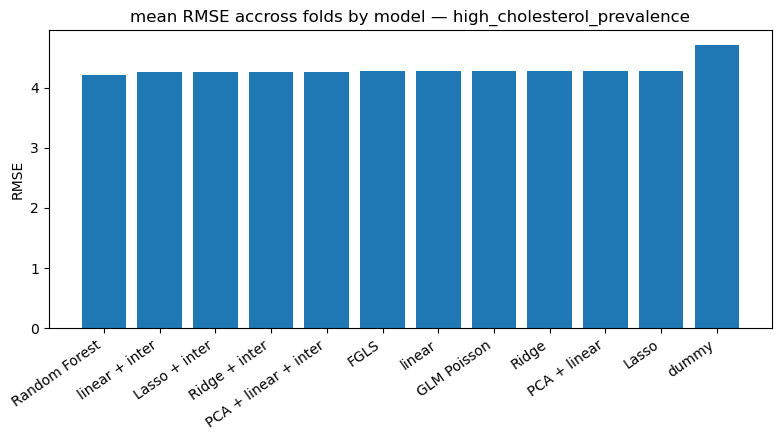

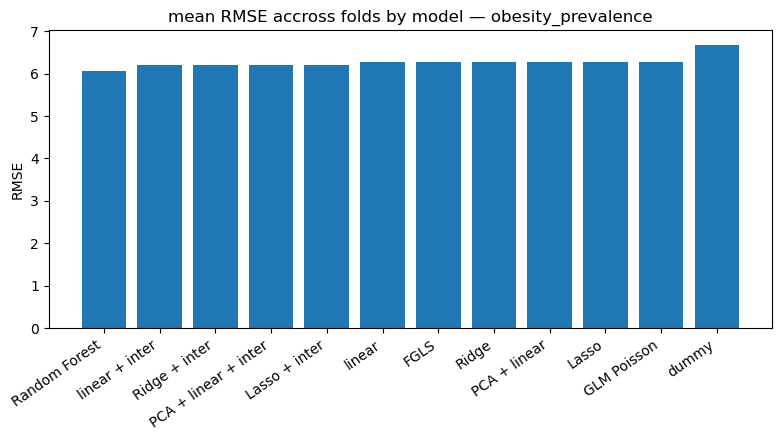

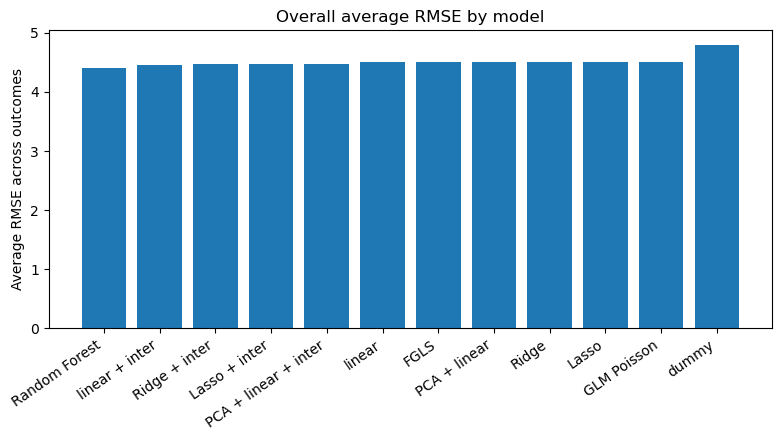

In [12]:
# Plotting

# Create a folder where all figures will be saved
outdir = "plots"
os.makedirs(outdir, exist_ok=True)  # exist_ok=True so there are no errors if the folder already exists


def plot_bars_for_target(sub, target, outdir):
    """
    Make a bar chart of RMSEs for a single outcome sorted from best (lowest RMSE) to worst.

    Parameters:
    sub = pd.DataFrame, Subset of `results` for one fixed outcome that has the columns: ["model", "rmse_mean"].
    target = str, Outcome name (used for the figure title and filename).
    outdir = str, Directory to save the PNG file.

    Returns:
    outpath = str, Path to the saved PNG.
    """
    
    sub = sub.sort_values("rmse_mean") # Sort so bars appear from lowest to highest RMSE
    x = np.arange(len(sub)) # x positions for the bars
    rmse = sub["rmse_mean"].values # Heights of the bars (the metric we care about)
    labels = sub["model"].values # labels of the bars

    # Build the figure
    plt.figure(figsize=(8, 4.5))
    plt.bar(x, rmse)
    plt.xticks(x, labels, rotation=35, ha="right")  # model labels on x-axis slightly rotated
    plt.ylabel("RMSE")
    plt.title(f"mean RMSE accross folds by model — {target}")
    plt.tight_layout()  # reduce clipping of labels

    # Save and display
    outpath = f"{outdir}/rmse_by_model_{target}.png"
    plt.savefig(outpath, dpi=150, bbox_inches="tight")
    plt.show()
    return outpath


# Per-outcome bar charts: one PNG per outcome
saved_pngs = []
for tgt, sub in results.groupby(
    "target"
):  # results.groupby("target") splits the DataFrame into one chunk per unique outcome
    saved_pngs.append(plot_bars_for_target(sub.copy(), tgt, outdir))


# Overall average RMSE bar chart (across outcomes)
x = np.arange(len(leaderboard))
plt.figure(figsize=(8, 4.5))
plt.bar(x, leaderboard["avg_rmse"].values)
plt.xticks(x, leaderboard["model"].values, rotation=35, ha="right")
plt.ylabel("Average RMSE across outcomes")
plt.title("Overall average RMSE by model")
plt.tight_layout()
overall_png = f"{outdir}/avg_rmse_by_model.png"
plt.savefig(overall_png, dpi=150, bbox_inches="tight")
plt.show()

#### Secondary KPI = R-squared

Below we provide the $R^2$ score per outcome for the `RandomForestResgressor` since it achieved the best RMSE (primary KPI) for each outcome.

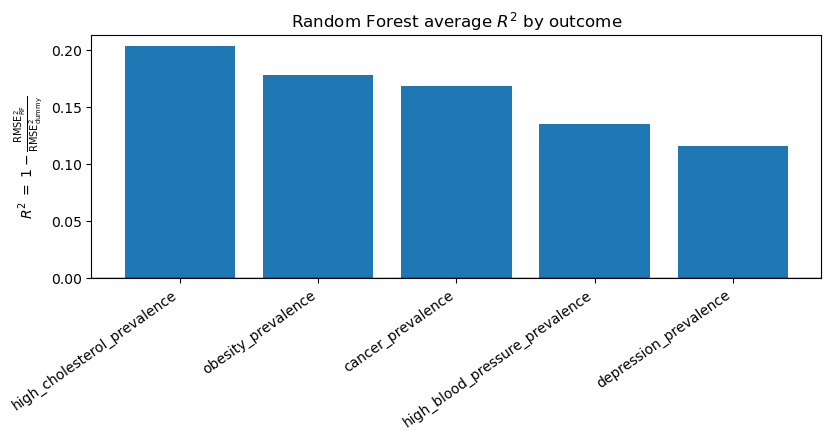

In [13]:
# Keeps only dummy baseline per outcome, keeps only the average RMSE per outcome, and renames the rmse_mean column as rmse_dummy
base = results[results["model"] == "dummy"][["target", "rmse_mean"]].rename(
    columns={"rmse_mean": "rmse_dummy"}
)

# Sme thing for RandomForestRegressor
best = results[results["model"] == "Random Forest"][["target", "rmse_mean"]].rename(
    columns={"rmse_mean": "rmse_rf"}
)

# Join dummy RMSE and compute R^2 = 1 - (RMSE_best^2 / RMSE_dummy^2)
best = best.merge(base, on="target", how="left")

best["R2_from_RMSE"] = 1.0 - (best["rmse_rf"] ** 2) / (best["rmse_dummy"] ** 2)

# Sort from highest to lowest R^2
best = best.sort_values("R2_from_RMSE", ascending=False).reset_index(drop=True)

# Save the .csv file
r2_csv_path = f"{outdir}/best_r2_by_outcome.csv"
best[["target", "rmse_rf", "rmse_dummy", "R2_from_RMSE"]].to_csv(
    r2_csv_path, index=False
)

# Plot and Save the bar chart
plt.figure(figsize=(8.5, 4.5))
x = np.arange(len(best))
plt.bar(x, best["R2_from_RMSE"].values)
plt.axhline(0.0, color="k", linewidth=1)
plt.xticks(x, best["target"].values, rotation=35, ha="right")
plt.ylabel(
    r"$R^2 \;=\; 1 - \frac{\mathrm{RMSE}^2_{\mathrm{RF}}}{\mathrm{RMSE}^2_{\mathrm{dummy}}}$"
)
plt.title("Random Forest average $R^2$ by outcome")
plt.tight_layout()

r2_png_path = f"{outdir}/best_r2_by_outcome.png"
plt.savefig(r2_png_path, dpi=150, bbox_inches="tight")
plt.show()